In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
from tensorflow.keras.metrics import Precision, Recall

from sklearn.preprocessing import label_binarize

In [2]:
TRAIN_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/train"
VAL_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/val"
TEST_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/test"

In [3]:
model = load_model(
    r"E:/ML Portfolio Projects/11. Retinopathy_Detection/models/densenet121_best.keras"
)

In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1234 images belonging to 3 classes.


Found 265 images belonging to 3 classes.
Found 265 images belonging to 3 classes.


In [7]:
print(train_generator.class_indices)

{'class_1': 0, 'class_2': 1, 'class_3': 2}


In [8]:
# Get training labels
train_labels = train_generator.classes

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights_dict)

Class Weights:
{0: np.float64(0.7254556143445032), 1: np.float64(1.033500837520938), 2: np.float64(1.5291201982651796)}


In [9]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [10]:
# Unfreeze the full base model
base_model.trainable = True

# Freeze lower layers, unfreeze top ~50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),

    loss='categorical_crossentropy',

    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

In [12]:
fine_tune_checkpoint = ModelCheckpoint(
    filepath=r"E:/ML Portfolio Projects/11. Retinopathy_Detection/models/densenet121_finetuned_best.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

fine_tune_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

fine_tune_lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

In [13]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stop,
        fine_tune_lr_reduce
    ]
)

Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.7856 - loss: 0.5317 - precision: 0.8012 - recall: 0.7559
Epoch 1: val_loss improved from None to 0.45998, saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/densenet121_finetuned_best.keras

Epoch 1: finished saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/densenet121_finetuned_best.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 57s 632ms/step - accuracy: 0.8006 - loss: 0.5047 - precision: 0.8176 - recall: 0.7771 - val_accuracy: 0.8000 - val_loss: 0.4600 - val_precision: 0.8200 - val_recall: 0.7736 - learning_rate: 1.0000e-05
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.7594 - loss: 0.5549 - precision: 0.7916 - recall: 0.7385
Epoch 2: val_loss did not improve from 0.45998
78/78 ━━━━━━━━━━━━━━━━━━━━ 47s 597ms/step - accuracy: 0.7820 - loss: 0.5333 - precision: 0.8015 - recall: 0.7593 - val_accuracy: 0.8038 - val_loss: 0.4621 - val_precision: 0.8207 - val_recall: 0.77

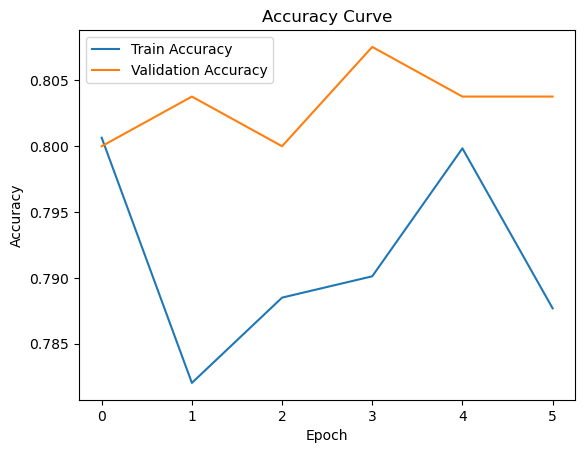

In [14]:
plt.plot(fine_tune_history.history['accuracy'], label='Train Accuracy')
plt.plot(fine_tune_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

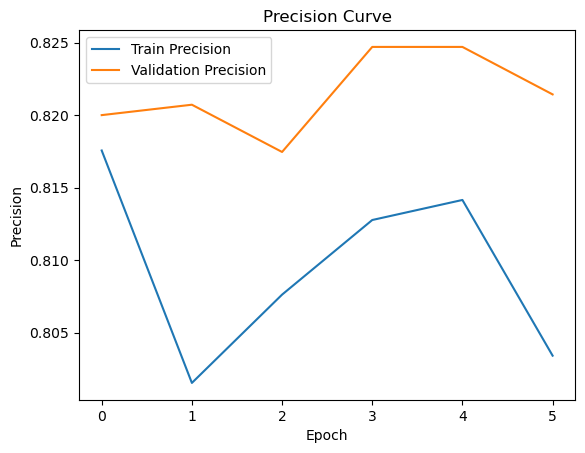

In [15]:
# PRECISION CURVE
plt.plot(fine_tune_history.history['precision'], label='Train Precision')
plt.plot(fine_tune_history.history['val_precision'], label='Validation Precision')

plt.title("Precision Curve")
plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.legend()
plt.show()

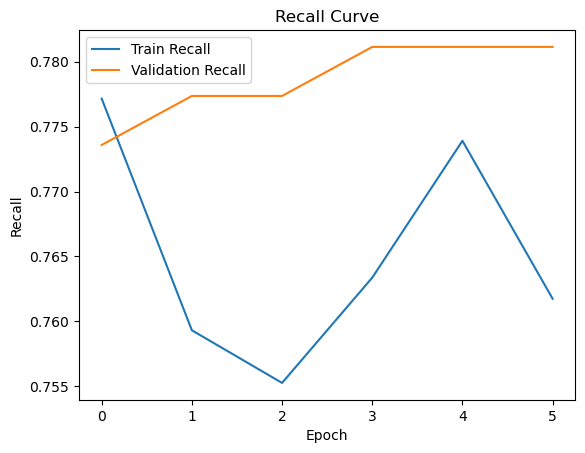

In [16]:
# RECALL CURVE
plt.plot(fine_tune_history.history['recall'], label='Train Recall')
plt.plot(fine_tune_history.history['val_recall'], label='Validation Recall')

plt.title("Recall Curve")
plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.legend()
plt.show()

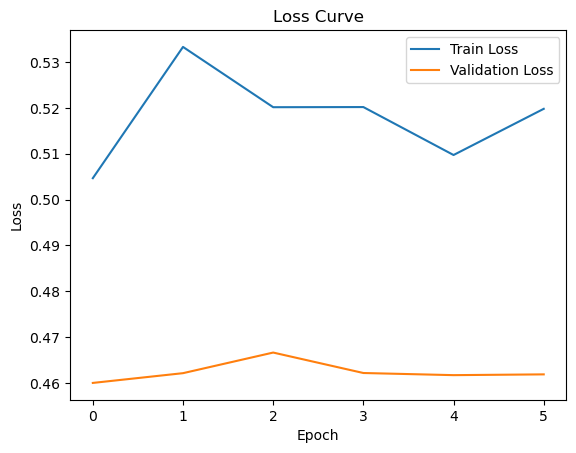

In [17]:
plt.plot(fine_tune_history.history['loss'], label='Train Loss')
plt.plot(fine_tune_history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [18]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 510ms/step - accuracy: 0.8151 - loss: 0.4203 - precision: 0.8313 - recall: 0.7811
Test Loss: 0.42030611634254456
Test Accuracy: 0.8150943517684937
Test Precision: 0.8313252925872803
Test Recall: 0.7811321020126343


In [19]:
# Predict probabilities
y_pred_probs = model.predict(test_generator)

# Convert probabilities to predicted classes
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 632ms/step


In [20]:
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

              precision    recall  f1-score   support

     class_1       0.91      0.98      0.94       122
     class_2       0.80      0.62      0.70        86
     class_3       0.65      0.77      0.70        57

    accuracy                           0.82       265
   macro avg       0.79      0.79      0.78       265
weighted avg       0.82      0.82      0.81       265



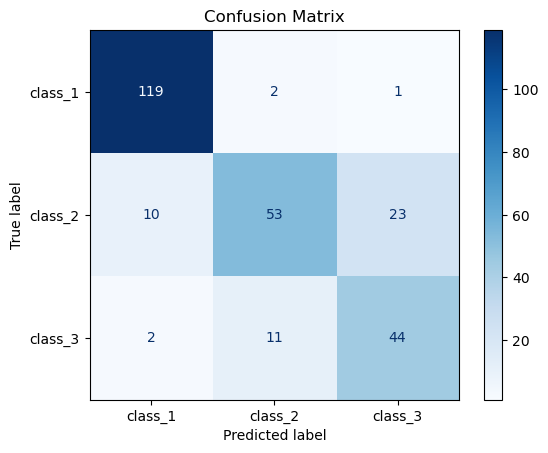

In [21]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")

plt.show()

In [22]:
# Convert labels to one-hot
y_true_bin = label_binarize(y_true, classes=[0,1,2])

# Compute ROC-AUC
roc_auc = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    multi_class='ovr'
)

print("Multiclass ROC-AUC:", roc_auc)

Multiclass ROC-AUC: 0.944941863813881
